<a href="https://colab.research.google.com/github/JuCaRiCo/202602-AnaliticaDescriptivaPredictiva/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo_271760.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Juan Carlos Rivera Cordova
- **Matrícula:** 271760

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [8]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.
mediaPrice = df['price'].mean()
medianaPrice = df['price'].median()
modaPrice = df['price'].mode()[0]

print('Media:',mediaPrice)
print('Mediana:',medianaPrice)
print('Moda:',modaPrice)


Media: 152.7206871868289
Mediana: 106.0
Moda: 100


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_La media y la mediana divergen considerablemente, Sugiere que el valor mas confiable es el de la medianam los valores de la media parecen estar cargados hacia la derecha, hacia lo mas alto

---
## Actividad 2 — Dispersión (20 pts)

In [10]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.
rango = df['price'].max() - df['price'].min()
print('Rango:',rango)

varianza = df['price'].var()
print('Varianza:',varianza)

std = df['price'].std()
print('Desviación estándar:',std)

q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
print('Q1:',q1)
print('Q3:',q3)
print('IQR:',iqr)

print('MAx:',df['price'].max())
print('Min:',df['price'].min())

Rango: 10000
Varianza: 57674.02524696084
Desviación estándar: 240.15416974718727
Q1: 69.0
Q3: 175.0
IQR: 106.0
MAx: 10000
Min: 0


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_El IQR nos muestra la variacion real de los precios, el rango no nos da informacion confiable, ya que el max es 10000, y el min es 0, el costo de 10000, da una falsa impresion de que hay variaciones en los precios, el IQR nos da un valor mas exacto porque saca tanto los precios bajos como los altos.

---
## Actividad 3 — Forma (20 pts)

In [11]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.
asimetria = df['price'].skew()
curtosis = df['price'].kurt()

print('Asimetría:',asimetria)
print('Curtosis:',curtosis)


Asimetría: 19.118938995046033
Curtosis: 585.6728788988286


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_en base a la asimetria  se podria explicar como que la mayoria de los precios son normales y solo unos cuantos se disparan, en resumen, los precios se encuentran entre baratos y medio, pero esos pocos que estan exageradamente caros son los que deforman las metricas

---
## Actividad 4 — Visualización (30 pts)

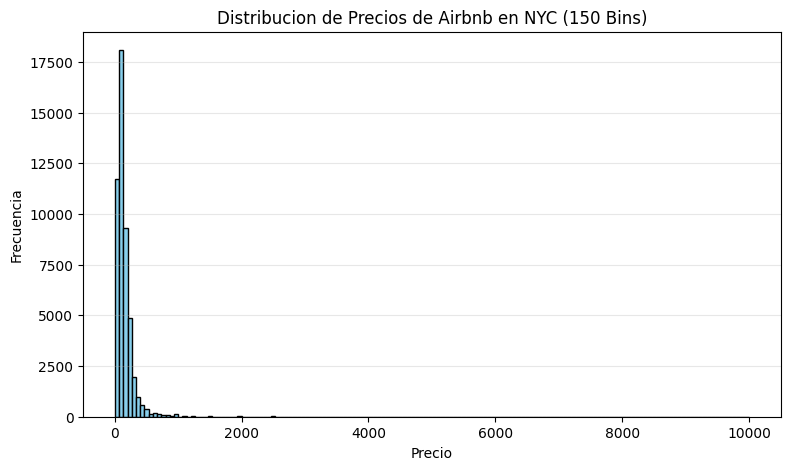

In [19]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.
df['price'].plot(
    kind='hist',
    bins=150,
    color='skyblue',
    edgecolor='black',
    figsize=(9, 5)
)

plt.title('Distribucion de Precios de Airbnb en NYC (150 Bins)')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()



RESPUESTA: 10 bins no permiten apreciar bien la acumulacion de diferentes precios, 50 parecia razonable, decidi por 150 para ver un poco mas clara la distrbucion.

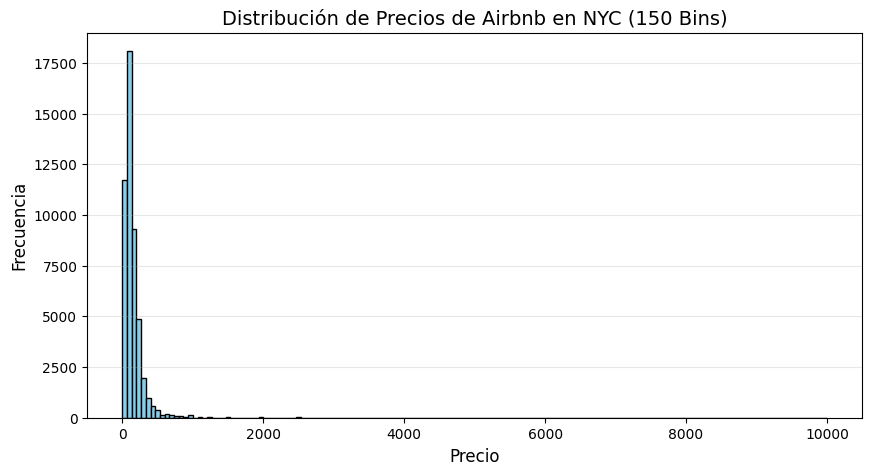

In [20]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.
plt.figure(figsize=(10, 5))

plt.hist(df['price'], bins=150, color='skyblue', edgecolor='black')

plt.title('Distribución de Precios de Airbnb en NYC (150 Bins)', fontsize=14)
plt.xlabel('Precio', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.show()



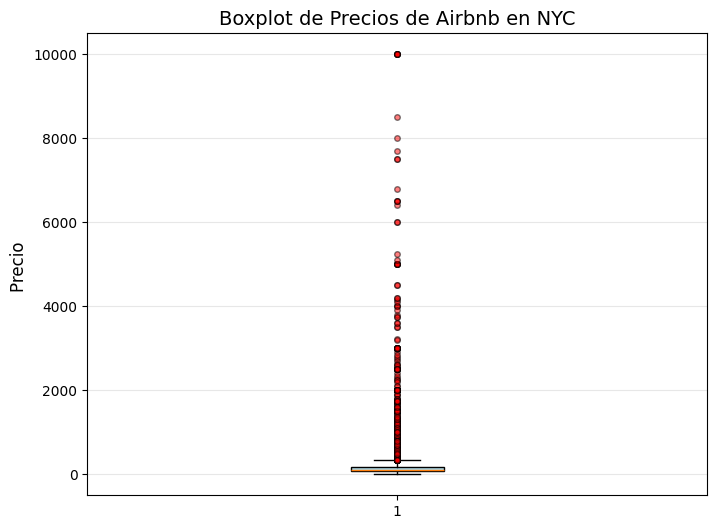

In [21]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).
plt.figure(figsize=(8, 6))

plt.boxplot(df['price'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))

plt.title('Boxplot de Precios de Airbnb en NYC', fontsize=14)
plt.ylabel('Precio ', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()



**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_El histograma muestra una concentracion en la zona iquierda y un vacio en la zona de la derecha, el boxplot tiene todo casi al fondo de la grafica y nos permite ver los valores atipicos que se extienden hasta 10000, para mi punto de vista es mas visible en el boxplot que en el histograma

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_El precio promedio de 152.72 da la falsa impresion de que los precios son caros, pero la realidad es que solo pocos precios que pueden llegar hasta 10000 hacen que el precio se alargue hacia arriba, por otro lado, lo que si nos da un precio mas normal es la mediana de 106 y el IQR de 69 a 175, lo cual demuestra que la generalidad ronda entre 106

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |